# 07 · TF-IDF and BM25 — the Stage 1 classical baseline

The project's first scored system, on the **leak-free** A1 split (`data/processed/fit/`,
task 3.2) — not the shipped `cnamuangtoun` partition, which leaks 99.8% of its test resumes
into train and is not reportable (see `docs/data/cards/A1-resume-job-description-fit.md`).

**This notebook reports the baseline; it does not define it.** Every model lives in
`candidate_screener.baselines`, and every figure below is read from the committed record
`output/baselines/baseline-metrics.json` rather than restated here. That split is deliberate:
three bugs shipped while the baseline existed only as notebook cells — two separately-fitted
vectorisers, a `.split()` BM25 tokeniser, and a BM25 corpus lookup that silently returned
`0.0` for every held-out resume. None raised, none changed a row count, all three produced a
plausible number. `tests/` now pins each one as a named regression, and `test_notebook_is_thin.py`
fails if model code is pasted back into these cells.

```bash
uv run python -m candidate_screener.baselines.run --seed 0    # rebuild the record
uv run python -m candidate_screener.baselines.run --check     # assert it still reproduces
uv run pytest                                                 # the regressions
```

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from candidate_screener.baselines import run
from candidate_screener.config import BASELINE_METRICS

pd.set_option("display.width", 100)

record = json.loads(BASELINE_METRICS.read_text(encoding="utf-8"))
print(BASELINE_METRICS.relative_to(BASELINE_METRICS.parents[2]))
print(record["split"]["note_not_comparable"])

output/baselines/baseline-metrics.json
Measured on the leak-free data/processed/fit/ split (task 3.2). NOT comparable to any number published against the shipped cnamuangtoun train/test partition, which leaks 99.8% of its test resumes into train.


## What was measured, and on what

Read from the record, so the prose here cannot drift from the numbers.

In [2]:
split = record["split"]
print(pd.DataFrame({name: split[name] for name in ("train", "test")}).T
      .drop(columns="label_counts"))
print()
print(pd.DataFrame({name: split[name]["label_counts"] for name in ("train", "test")}))
print()
print(f"shared TF-IDF vocabulary: {record['vocabulary']['size']} terms "
      f"(sha256 {record['vocabulary']['sha256'][:12]}…)")
print(f"skill keyword list:      sha256 {record['config']['skill_patterns_sha256'][:12]}…")

      pairs unique_resumes unique_jds
train  3990            446        245
test    659            158        100

               train  test
Good Fit         953   182
Potential Fit   1060   133
No Fit          1977   344

shared TF-IDF vocabulary: 5000 terms (sha256 424627ebb062…)
skill keyword list:      sha256 aeee52261870…


## Headline figures, against the floor they must be read with

The floor is *"always predict the commonest class"*. It is carried inside every `Report`
rather than recomputed by each caller, because accuracy below the floor is the single most
misreadable number this baseline produces.

In [3]:
floor = record["floor"]
rows = [{"model": name,
         "accuracy": record["models"][name]["accuracy"],
         "macro_f1": record["models"][name]["macro_f1"]}
        for name in run.MODELS]
rows.append({"model": f"floor (always {floor['majority_class']})",
             "accuracy": floor["accuracy"], "macro_f1": floor["macro_f1"]})
headline = pd.DataFrame(rows).set_index("model").round(4)
print(headline)
print()
for name in run.MODELS:
    m = record["models"][name]
    print(f"{name}: macro-F1 {'above' if m['macro_f1'] > floor['macro_f1'] else 'at or below'}"
          f" the floor, accuracy {'above' if m['accuracy'] > floor['accuracy'] else 'below'}"
          f" it (n={m['n']})")

                       accuracy  macro_f1
model                                    
tfidf                    0.4917    0.3818
bm25                     0.4598    0.3466
floor (always No Fit)    0.5220    0.2286

tfidf: macro-F1 above the floor, accuracy below it (n=659)
bm25: macro-F1 above the floor, accuracy below it (n=659)


**Both models beat the floor on macro-F1 and neither beats it on accuracy.**

That is the expected behaviour of one linear threshold over three overlapping, imbalanced
classes, not a defect. `class_weight="balanced"` buys recall on the two minority classes at
the cost of the majority class the floor is made of, so macro-F1 rises while accuracy falls
below 52.2%. Written down here and in `output/baselines/README.md` so it stops being reopened
as a bug.

## Per-class figures and the confusion matrices

Where the accuracy actually goes. Read from the record.

In [4]:
for name in run.MODELS:
    m = record["models"][name]
    print(f"=== {name}")
    per_class = pd.DataFrame(m["per_class"]).T
    print(per_class.round(4).astype({"support": int}))
    print(pd.DataFrame(m["confusion"],
                       index=[f"true: {label}" for label in m["per_class"]],
                       columns=[f"pred: {label}" for label in m["per_class"]]))
    print()

=== tfidf
               precision  recall      f1  support
Good Fit          0.3608  0.5055  0.4211      182
Potential Fit     0.2162  0.0602  0.0941      133
No Fit            0.6104  0.6512  0.6301      344
                     pred: Good Fit  pred: Potential Fit  pred: No Fit
true: Good Fit                   92                   12            78
true: Potential Fit              60                    8            65
true: No Fit                    103                   17           224

=== bm25
               precision  recall      f1  support
Good Fit          0.3433  0.5055  0.4089      182
Potential Fit     0.2105  0.0301  0.0526      133
No Fit            0.5565  0.6017  0.5782      344
                     pred: Good Fit  pred: Potential Fit  pred: No Fit
true: Good Fit                   92                    8            82
true: Potential Fit              46                    4            83
true: No Fit                    130                    7           207



`Potential Fit` is where both models collapse — it is the middle of an ordinal scale being
predicted from a single scalar, so it is squeezed out between the two ends. This is the most
informative failure in the table and the obvious thing for a later stage to attack.

## Score distributions by class

The analysis the committed record cannot express: *why* one threshold gets this far and no
further. Scores are recomputed through `baselines.run.build`, the same single definition the
record was frozen from — so if these cells disagree with the tables above, the notebook is
wrong, not the record.

In [5]:
built = run.build(seed=record["config"]["seed"])
test = built["test"]
scores = pd.DataFrame({"label": test.label.to_numpy(),
                       **{name: built["scores"][name]["test"] for name in run.MODELS}})

for name in run.MODELS:
    print(f"=== {name} (test)")
    print(scores.groupby("label")[name].agg(["count", "mean", "median", "std"]).round(4))
    print()

=== tfidf (test)
               count    mean  median     std
label                                       
Good Fit         182  0.1142  0.1011  0.0679
No Fit           344  0.0859  0.0642  0.0707
Potential Fit    133  0.1177  0.0877  0.0945

=== bm25 (test)
               count      mean    median       std
label                                             
Good Fit         182  343.5519  354.6070  176.6805
No Fit           344  308.9880  250.3873  229.8546
Potential Fit    133  308.0215  198.4159  270.9361



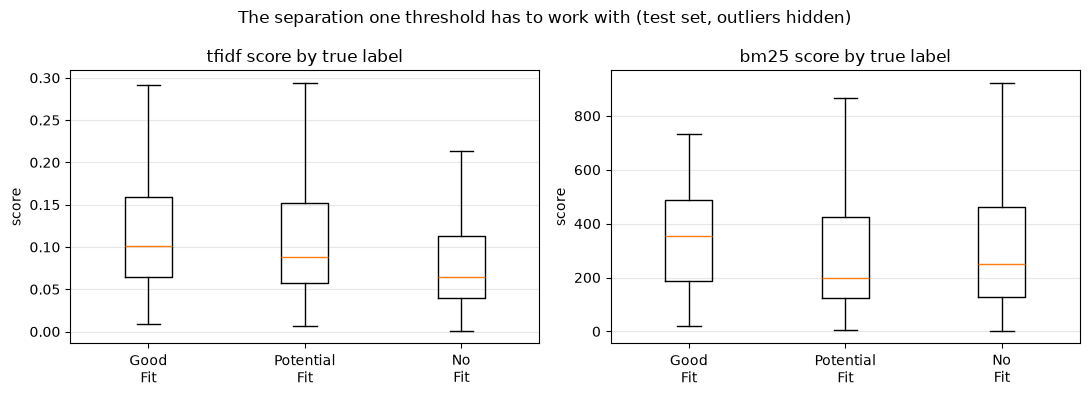

In [6]:
ORDER = ["Good Fit", "Potential Fit", "No Fit"]
fig, axes = plt.subplots(1, len(run.MODELS), figsize=(11, 4))
for ax, name in zip(axes, run.MODELS):
    ax.boxplot([scores.loc[scores.label == label, name] for label in ORDER],
               tick_labels=[label.replace(" ", "\n") for label in ORDER], showfliers=False)
    ax.set_title(f"{name} score by true label")
    ax.set_ylabel("score")
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("The separation one threshold has to work with (test set, outliers hidden)")
fig.tight_layout()
plt.show()

The boxes overlap almost completely, and the class means say why one threshold cannot do much
better than this:

- For both scorers `Good Fit` sits above `No Fit` — the right direction — but by about **0.03**
  of cosine (0.114 vs 0.086) against a within-class standard deviation of 0.07, so the signal is
  a fraction of the noise.
- **`Potential Fit` scores *higher* on the mean than `Good Fit`** on both scorers, with by far
  the widest spread (std 0.094 for TF-IDF, 271 for BM25). Its mean carries no ordinal
  information at all, which is the direct cause of the 0.09 / 0.05 F1 in the tables above: a
  monotone threshold on this feature cannot place a class whose scores straddle both others.

**That is the finding.** It sets the bar the semantic and cross-encoder stages have to clear, and
it is why the next stage is a different representation rather than a better threshold on this one.


## Does the record still reproduce?

The same check `uv run python -m candidate_screener.baselines.run --check` runs, and the same
one `tests/test_baseline_golden.py` wraps.

In [7]:
for ok, message in run.check(run.metrics_document(built), record):
    print(f"[{'PASS' if ok else 'FAIL'}] {message}")

[PASS] split: reproduces the committed record
[PASS] config: reproduces the committed record
[PASS] vocabulary: reproduces the committed record
[PASS] floor: reproduces the committed record
[PASS] models: reproduces the committed record


## Where this leaves the project

| | |
|---|---|
| Best classical figure | macro-F1 **0.3818** (TF-IDF cosine), against a **0.2286** floor |
| The number that is *not* beaten | accuracy — 0.4917 against a 0.5220 floor, and expectedly so |
| Weakest class | `Potential Fit`, F1 0.09 / 0.05 — the middle of an ordinal scale from one scalar |
| Comparable to | every other Stage 1–4 figure on `data/processed/fit/`. **Not** to any published number on the shipped partition |

Deliberately not done here, and tracked rather than forgotten:

- **The skill list is hand-written**, not learned. `data/vocab/` (task 3.5) is being built for
  exactly this and is not consumed — swapping it in is a modelling change that would move every
  number above (assumption A9).
- **Retrieval metrics** — Recall@10, Precision@5, nDCG@10 on the task 3.3 pools — are not
  reported (Q24). This notebook scores the 3-class label task; the pools score ranking, and the
  random-ranker floor for them is already measured in `evaluation.metrics --sanity`.